[*********************100%***********************]  1 of 1 completed


             Adj Close
Date                  
2020-01-02  302.208679
2020-01-03  299.920319
2020-01-06  301.064362
2020-01-07  300.217957
2020-01-08  301.817932


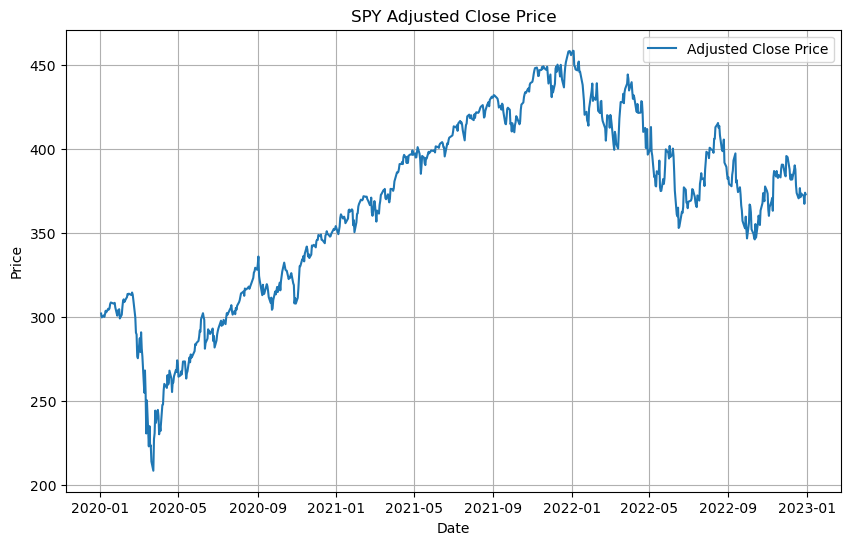

In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Download historical price data
def get_data(ticker, start_date, end_date):
    """
    Fetch historical price data for a specific asset.

    Parameters:
        ticker (str): The stock/ETF ticker symbol.
        start_date (str): Start date in the format 'YYYY-MM-DD'.
        end_date (str): End date in the format 'YYYY-MM-DD'.

    Returns:
        pd.DataFrame: DataFrame containing the adjusted close price.
    """
    data = yf.download(ticker, start=start_date, end=end_date)
    return data[["Adj Close"]]

if __name__ == "__main__":
    # Fetch data for SPY ETF as an example
    ticker = "SPY"
    start_date = "2020-01-01"
    end_date = "2023-01-01"

    data = get_data(ticker, start_date, end_date)

    # Display the first few rows of data
    print(data.head())

    # Plot the adjusted close price
    plt.figure(figsize=(10, 6))
    plt.plot(data["Adj Close"], label="Adjusted Close Price")
    plt.title(f"{ticker} Adjusted Close Price")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid()
    plt.show()


             Adj Close  Daily Return
Date                                
2020-01-03  299.920319     -0.007572
2020-01-06  301.064362      0.003814
2020-01-07  300.217957     -0.002811
2020-01-08  301.817932      0.005329
2020-01-09  303.864441      0.006781


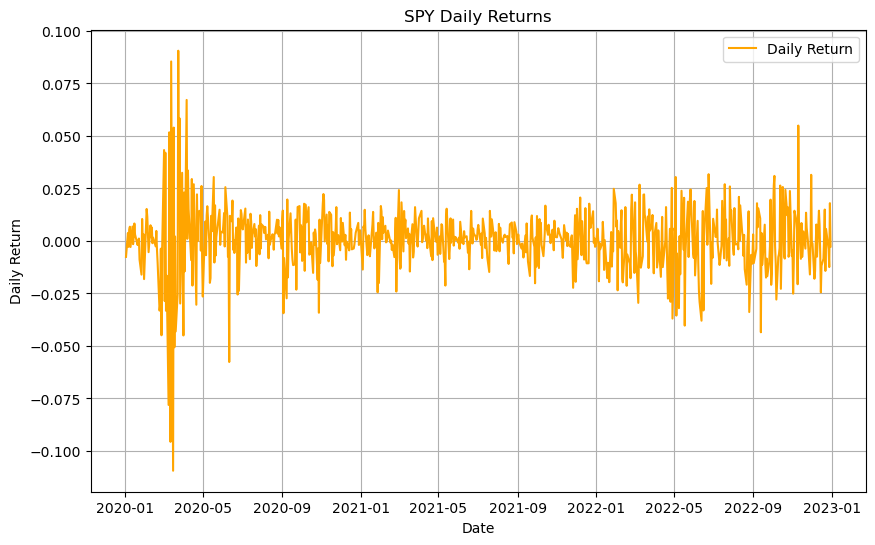

In [4]:
#Calculate daily returns
def calculate_returns(data):
    """
    Calculate daily returns from adjusted close prices.

    Parameters:
        data (pd.DataFrame): DataFrame containing adjusted close prices.

    Returns:
        pd.DataFrame: DataFrame with daily returns added as a new column.
    """
    data = data.copy()
    data["Daily Return"] = data["Adj Close"].pct_change()
    return data.dropna()


if __name__ == "__main__":
    # Add daily returns to the data
    data = calculate_returns(data)

    # Display the first few rows to verify
    print(data[["Adj Close", "Daily Return"]].head())

    # Plot daily returns
    plt.figure(figsize=(10, 6))
    plt.plot(data["Daily Return"], label="Daily Return", color="orange")
    plt.title(f"{ticker} Daily Returns")
    plt.xlabel("Date")
    plt.ylabel("Daily Return")
    plt.legend()
    plt.grid()
    plt.show()


In [5]:
from arch import arch_model


# Fit GARCH model
def fit_garch_rescaled(returns):
    """
    Fit a GARCH(1,1) model to the rescaled daily returns.

    Parameters:
        returns (pd.Series): Series of daily returns.

    Returns:
        arch.arch_model.result.Result: Fitted GARCH model.
    """
    # Rescale returns
    scaled_returns = returns * 100

    # Fit GARCH model
    model = arch_model(scaled_returns, vol='Garch', p=1, q=1)
    fitted_model = model.fit(disp='off')
    return fitted_model, scaled_returns

if __name__ == "__main__":
    # Drop NaN values in daily returns
    returns = data["Daily Return"].dropna()

    # Fit GARCH model with rescaled returns
    garch_model_rescaled, scaled_returns = fit_garch_rescaled(returns)

    # Display the summary of the GARCH model
    print(garch_model_rescaled.summary())


                     Constant Mean - GARCH Model Results                      
Dep. Variable:           Daily Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1220.30
Distribution:                  Normal   AIC:                           2448.60
Method:            Maximum Likelihood   BIC:                           2467.10
                                        No. Observations:                  755
Date:                Wed, Dec 11 2024   Df Residuals:                      754
Time:                        23:00:10   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0867  3.772e-02      2.299  2.153e-02 [1.277e-0

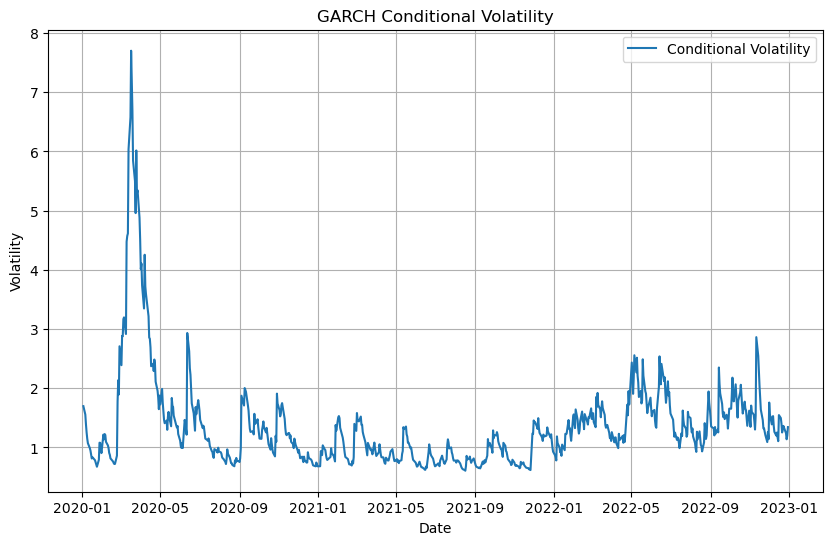

In [6]:
#  Plot conditional volatility
def plot_conditional_volatility(fitted_model, data, returns):
    """
    Plot the conditional volatility of the GARCH model.

    Parameters:
        fitted_model (arch.arch_model.result.Result): Fitted GARCH model.
        data (pd.DataFrame): Original data.
        returns (pd.Series): Series of daily returns.
    """
    # Add conditional volatility to the data
    data["GARCH_Volatility"] = fitted_model.conditional_volatility

    # Plot conditional volatility
    plt.figure(figsize=(10, 6))
    plt.plot(data["GARCH_Volatility"], label="Conditional Volatility")
    plt.title("GARCH Conditional Volatility")
    plt.xlabel("Date")
    plt.ylabel("Volatility")
    plt.legend()
    plt.grid()
    plt.show()

if __name__ == "__main__":
    # Plot the conditional volatility
    plot_conditional_volatility(garch_model_rescaled, data, scaled_returns)


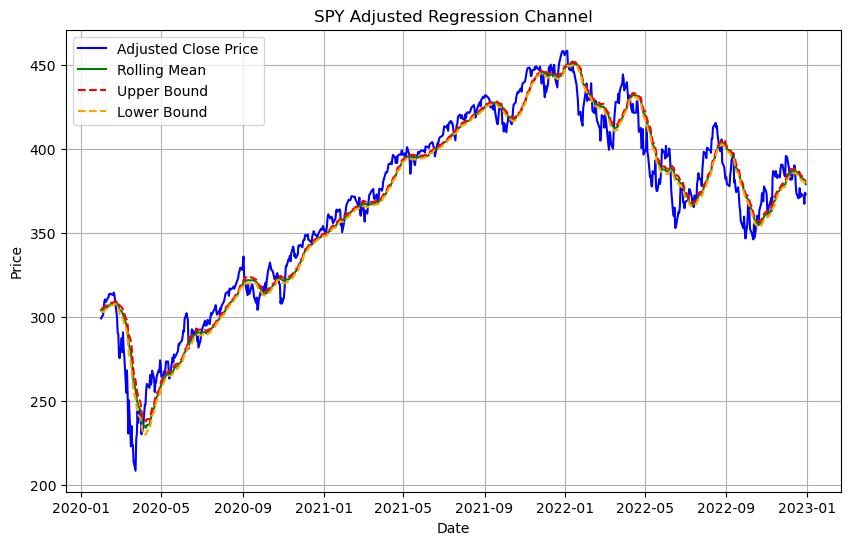

In [7]:
# Adjust regression channel with GARCH volatility
def adjust_regression_channel(data, rolling_window=20, factor=1.5):
    """
    Adjust regression channel based on rolling mean and GARCH conditional volatility.

    Parameters:
        data (pd.DataFrame): Data containing 'Adj Close', 'GARCH_Volatility'.
        rolling_window (int): Window size for rolling mean calculation.
        factor (float): Multiplier for GARCH volatility to calculate channel boundaries.

    Returns:
        pd.DataFrame: DataFrame with adjusted upper and lower channel boundaries.
    """
    # Calculate rolling mean
    data["RollingMean"] = data["Adj Close"].rolling(window=rolling_window).mean()

    # Calculate upper and lower bounds
    data["UpperBound"] = data["RollingMean"] + factor * data["GARCH_Volatility"]
    data["LowerBound"] = data["RollingMean"] - factor * data["GARCH_Volatility"]

    return data.dropna()

if __name__ == "__main__":
    # Adjust regression channel
    data = adjust_regression_channel(data, rolling_window=20, factor=1.0)  


    # Plot adjusted regression channel
    plt.figure(figsize=(10, 6))
    plt.plot(data["Adj Close"], label="Adjusted Close Price", color="blue")
    plt.plot(data["RollingMean"], label="Rolling Mean", color="green")
    plt.plot(data["UpperBound"], label="Upper Bound", linestyle="--", color="red")
    plt.plot(data["LowerBound"], label="Lower Bound", linestyle="--", color="orange")
    plt.title(f"{ticker} Adjusted Regression Channel")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid()
    plt.show()


In [8]:
# Update: Adding cooldown period logic
def backtest_strategy_with_cooldown(data, initial_balance=10000, cooldown=5):
    """
    Backtest a trading strategy based on regression channel with a cooldown period.

    Parameters:
        data (pd.DataFrame): Data containing 'Adj Close', 'UpperBound', 'LowerBound'.
        initial_balance (float): Starting capital for backtesting.
        cooldown (int): Number of days to wait before making another trade.

    Returns:
        float: Final portfolio value after backtesting.
    """
    balance = initial_balance
    position = 0  # Number of shares held
    last_trade = -cooldown  # Initialize last trade day

    for i in range(1, len(data)):
        if i - last_trade < cooldown:
            continue  # Skip if within cooldown period

        if data["Adj Close"].iloc[i] < data["LowerBound"].iloc[i] and position == 0:
            # Buy signal
            position = balance / data["Adj Close"].iloc[i]
            balance = 0
            last_trade = i
        elif data["Adj Close"].iloc[i] > data["UpperBound"].iloc[i] and position > 0:
            # Sell signal
            balance = position * data["Adj Close"].iloc[i]
            position = 0
            last_trade = i

    # Final portfolio value
    final_value = balance + position * data["Adj Close"].iloc[-1]
    return final_value


In [9]:
if __name__ == "__main__":
    # Test different cooldown periods
    cooldown_periods = [3, 5, 7, 10]
    for cooldown in cooldown_periods:
        final_portfolio_value = backtest_strategy_with_cooldown(data, cooldown=cooldown)
        print(f"Final Portfolio Value with {cooldown}-day Cooldown: ${final_portfolio_value:.2f}")



Final Portfolio Value with 3-day Cooldown: $11566.48
Final Portfolio Value with 5-day Cooldown: $11698.29
Final Portfolio Value with 7-day Cooldown: $10405.62
Final Portfolio Value with 10-day Cooldown: $12721.15


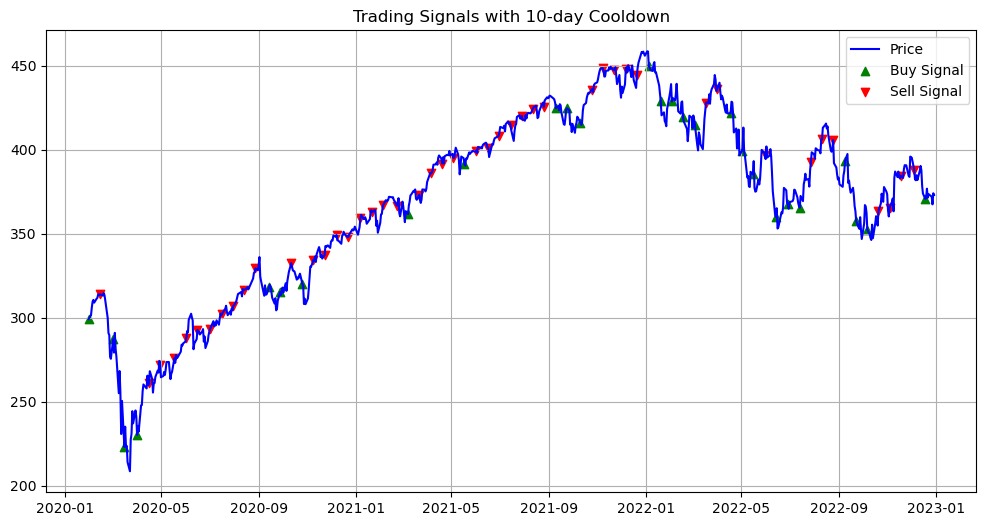

In [10]:
# Visualize trading signals for a 10-day cooldown
def visualize_signals(data, cooldown=10):
    """
    Visualize buy and sell signals for the given cooldown period.

    Parameters:
        data (pd.DataFrame): Data containing 'Adj Close', 'UpperBound', 'LowerBound'.
        cooldown (int): Cooldown period for trading.
    """
    # Run the strategy with cooldown
    backtest_strategy_with_cooldown(data, cooldown=cooldown)

    # Generate buy/sell signals
    buy_signals = []
    sell_signals = []
    last_trade = -cooldown

    for i in range(len(data)):
        if i - last_trade < cooldown:
            buy_signals.append(None)
            sell_signals.append(None)
            continue

        if data["Adj Close"].iloc[i] < data["LowerBound"].iloc[i]:
            buy_signals.append(data["Adj Close"].iloc[i])
            sell_signals.append(None)
            last_trade = i
        elif data["Adj Close"].iloc[i] > data["UpperBound"].iloc[i]:
            sell_signals.append(data["Adj Close"].iloc[i])
            buy_signals.append(None)
            last_trade = i
        else:
            buy_signals.append(None)
            sell_signals.append(None)

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(data["Adj Close"], label="Price", color="blue")
    plt.scatter(data.index, buy_signals, label="Buy Signal", marker="^", color="green")
    plt.scatter(data.index, sell_signals, label="Sell Signal", marker="v", color="red")
    plt.title(f"Trading Signals with {cooldown}-day Cooldown")
    plt.legend()
    plt.grid()
    plt.show()


visualize_signals(data, cooldown=10)


In [11]:
def adjust_dynamic_channel(data, factor=1.5):
    """
    Adjust regression channel dynamically based on GARCH volatility.

    Parameters:
        data (pd.DataFrame): Data containing 'Adj Close' and 'GARCH_Volatility'.
        factor (float): Multiplier for GARCH volatility to calculate channel boundaries.

    Returns:
        pd.DataFrame: DataFrame with dynamically adjusted channel boundaries.
    """
    data["RollingMean"] = data["Adj Close"].rolling(window=20).mean()
    data["UpperBound"] = data["RollingMean"] + factor * data["GARCH_Volatility"]
    data["LowerBound"] = data["RollingMean"] - factor * data["GARCH_Volatility"]
    return data


In [12]:
data = adjust_dynamic_channel(data, factor=1.5)


In [13]:
# Backtest strategy with the dynamically adjusted channel
final_portfolio_value_dynamic = backtest_strategy_with_cooldown(data, cooldown=10)
print(f"Final Portfolio Value with Dynamic Channel and 10-day Cooldown: ${final_portfolio_value_dynamic:.2f}")


Final Portfolio Value with Dynamic Channel and 10-day Cooldown: $10382.65


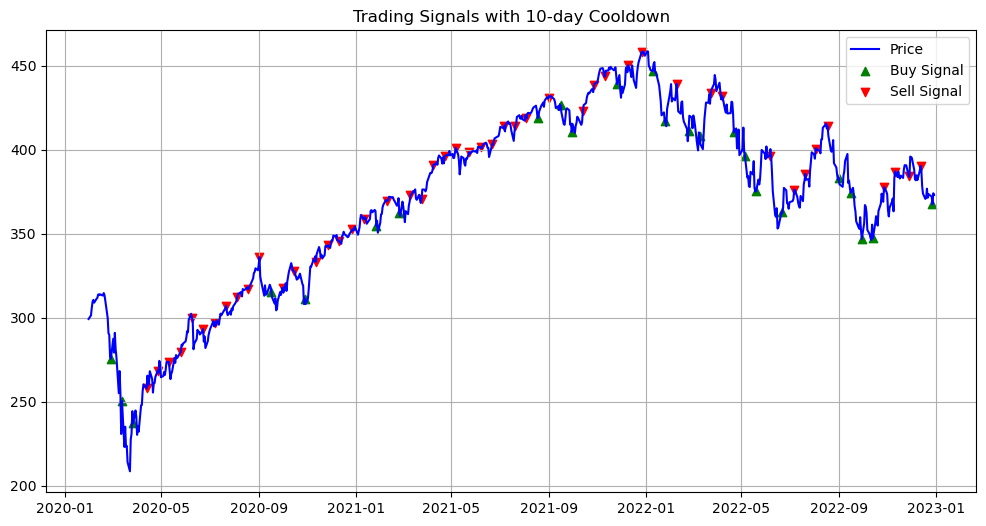

In [14]:
# Visualize trading signals with dynamic channel and cooldown
visualize_signals(data, cooldown=10)


In [15]:
def backtest_strategy_with_trend_filter(data, initial_balance=10000, cooldown=10):
    """
    Backtest a trading strategy with trend filtering and cooldown period.

    Parameters:
        data (pd.DataFrame): Data containing 'Adj Close', 'UpperBound', 'LowerBound', 'ShortMA', 'LongMA'.
        initial_balance (float): Starting capital for backtesting.
        cooldown (int): Number of days to wait before making another trade.

    Returns:
        float: Final portfolio value after backtesting.
    """
    balance = initial_balance
    position = 0  # Number of shares held
    last_trade = -cooldown  # Initialize last trade day

    for i in range(1, len(data)):
        if i - last_trade < cooldown:
            continue  # Skip if within cooldown period

        # Buy signal: Price < LowerBound and short-term MA > long-term MA
        if (
            data["Adj Close"].iloc[i] < data["LowerBound"].iloc[i]
            and data["ShortMA"].iloc[i] > data["LongMA"].iloc[i]
            and position == 0
        ):
            position = balance / data["Adj Close"].iloc[i]
            balance = 0
            last_trade = i

        # Sell signal: Price > UpperBound and short-term MA < long-term MA
        elif (
            data["Adj Close"].iloc[i] > data["UpperBound"].iloc[i]
            and data["ShortMA"].iloc[i] < data["LongMA"].iloc[i]
            and position > 0
        ):
            balance = position * data["Adj Close"].iloc[i]
            position = 0
            last_trade = i

    # Final portfolio value
    final_value = balance + position * data["Adj Close"].iloc[-1]
    return final_value


In [16]:
data["ShortMA"] = data["Adj Close"].rolling(window=10).mean()  # 10-day moving average
data["LongMA"] = data["Adj Close"].rolling(window=50).mean()  # 50-day moving average


In [17]:
# Backtest with trend filtering
final_portfolio_value_with_trend = backtest_strategy_with_trend_filter(data, cooldown=10)
print(f"Final Portfolio Value with Trend Filter and 10-day Cooldown: ${final_portfolio_value_with_trend:.2f}")


Final Portfolio Value with Trend Filter and 10-day Cooldown: $12192.63


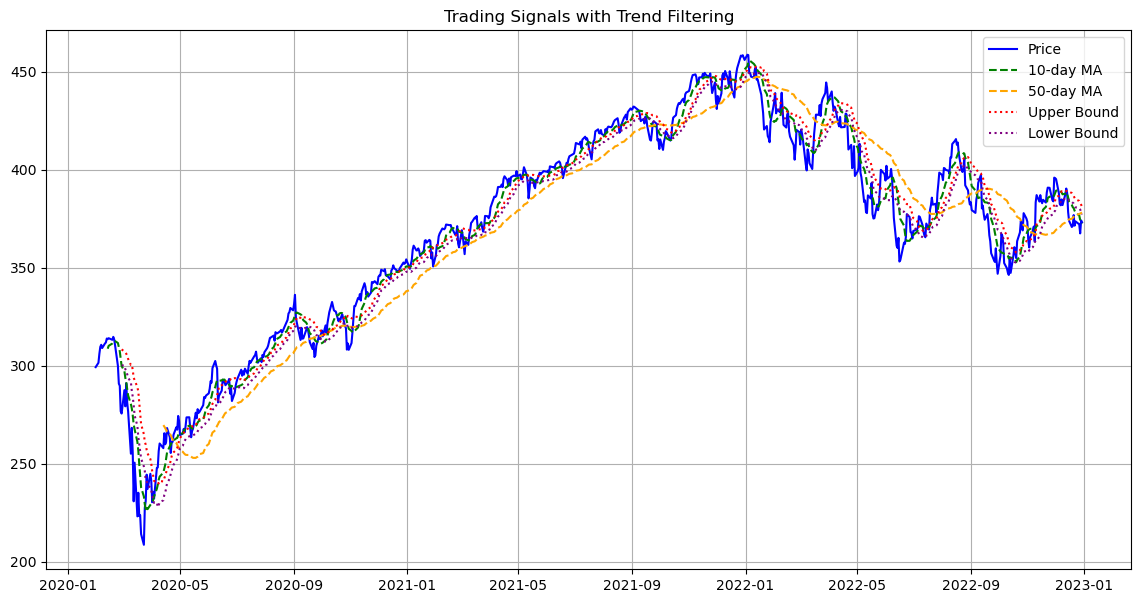

In [18]:
# Visualize signals with trend filtering
def visualize_signals_with_trend(data):
    """
    Visualize buy and sell signals along with short-term and long-term moving averages.

    Parameters:
        data (pd.DataFrame): Data containing 'Adj Close', 'ShortMA', 'LongMA', 'UpperBound', 'LowerBound'.
    """
    plt.figure(figsize=(14, 7))
    plt.plot(data.index, data["Adj Close"], label="Price", color="blue")
    plt.plot(data.index, data["ShortMA"], label="10-day MA", color="green", linestyle="--")
    plt.plot(data.index, data["LongMA"], label="50-day MA", color="orange", linestyle="--")
    plt.plot(data.index, data["UpperBound"], label="Upper Bound", color="red", linestyle=":")
    plt.plot(data.index, data["LowerBound"], label="Lower Bound", color="purple", linestyle=":")
    plt.title("Trading Signals with Trend Filtering")
    plt.legend()
    plt.grid()
    plt.show()

visualize_signals_with_trend(data)


In [19]:
# Calculate evaluation metrics
def calculate_metrics(data, returns):
    """
    Calculate evaluation metrics for the strategy.

    Parameters:
        data (pd.DataFrame): Data containing 'Adj Close'.
        returns (pd.Series): Series of daily returns.

    Returns:
        dict: Dictionary containing maximum drawdown, annualized return, and Sharpe ratio.
    """
    # Maximum drawdown
    cumulative = (1 + returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_drawdown = drawdown.min()

    # Annualized return
    annualized_return = (1 + returns.mean())**252 - 1

    # Sharpe ratio
    sharpe_ratio = returns.mean() / returns.std() * (252**0.5)

    return {
        "Max Drawdown": max_drawdown,
        "Annualized Return": annualized_return,
        "Sharpe Ratio": sharpe_ratio,
    }

metrics = calculate_metrics(data, returns)
print("\nStrategy Evaluation Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.2%}" if metric != "Sharpe Ratio" else f"{metric}: {value:.2f}")



Strategy Evaluation Metrics:
Max Drawdown: -33.72%
Annualized Return: 10.72%
Sharpe Ratio: 0.41


In [20]:
def backtest_strategy_with_stop_loss(data, initial_balance=10000, cooldown=10, stop_loss=0.9):
    """
    Backtest a trading strategy with trend filtering, cooldown period, and stop-loss.

    Parameters:
        data (pd.DataFrame): Data containing 'Adj Close', 'UpperBound', 'LowerBound', 'ShortMA', 'LongMA'.
        initial_balance (float): Starting capital for backtesting.
        cooldown (int): Number of days to wait before making another trade.
        stop_loss (float): Stop-loss threshold (e.g., 0.9 means 10% loss from the buy price).

    Returns:
        float: Final portfolio value after backtesting.
    """
    balance = initial_balance
    position = 0  # Number of shares held
    last_trade = -cooldown  # Initialize last trade day
    buy_price = 0  # Record the buy price for stop-loss

    for i in range(1, len(data)):
        if i - last_trade < cooldown:
            continue  # Skip if within cooldown period

        # Buy signal: Price < LowerBound and short-term MA > long-term MA
        if (
            data["Adj Close"].iloc[i] < data["LowerBound"].iloc[i]
            and data["ShortMA"].iloc[i] > data["LongMA"].iloc[i]
            and position == 0
        ):
            position = balance / data["Adj Close"].iloc[i]
            buy_price = data["Adj Close"].iloc[i]
            balance = 0
            last_trade = i

        # Sell signal: Price > UpperBound and short-term MA < long-term MA
        elif (
            data["Adj Close"].iloc[i] > data["UpperBound"].iloc[i]
            and data["ShortMA"].iloc[i] < data["LongMA"].iloc[i]
            and position > 0
        ):
            balance = position * data["Adj Close"].iloc[i]
            position = 0
            last_trade = i

        # Stop-loss: If price falls below stop-loss threshold
        elif (
            position > 0
            and data["Adj Close"].iloc[i] < stop_loss * buy_price
        ):
            balance = position * data["Adj Close"].iloc[i]
            position = 0
            last_trade = i

    # Final portfolio value
    final_value = balance + position * data["Adj Close"].iloc[-1]
    return final_value


In [21]:
# Backtest with stop-loss logic
final_portfolio_value_with_stop_loss = backtest_strategy_with_stop_loss(data, cooldown=10, stop_loss=0.9)
print(f"Final Portfolio Value with Stop-Loss and 10-day Cooldown: ${final_portfolio_value_with_stop_loss:.2f}")


Final Portfolio Value with Stop-Loss and 10-day Cooldown: $11713.56


In [22]:
# Recalculate evaluation metrics for the new strategy
metrics_with_stop_loss = calculate_metrics(data, returns)

print("\nStrategy Evaluation Metrics with Stop-Loss:")
for metric, value in metrics_with_stop_loss.items():
    print(f"{metric}: {value:.2%}" if metric != "Sharpe Ratio" else f"{metric}: {value:.2f}")



Strategy Evaluation Metrics with Stop-Loss:
Max Drawdown: -33.72%
Annualized Return: 10.72%
Sharpe Ratio: 0.41


In [23]:
def analyze_stop_loss(data, stop_loss=0.9):
    triggered = 0
    for i in range(1, len(data)):
        if data["Adj Close"].iloc[i] < stop_loss * data["Adj Close"].iloc[i - 1]:
            triggered += 1
    print(f"Stop-loss triggered {triggered} times.")
analyze_stop_loss(data, stop_loss=0.95)


Stop-loss triggered 5 times.


In [24]:
# Backtest with stop-loss threshold of 0.95
final_portfolio_value_with_stop_loss_95 = backtest_strategy_with_stop_loss(data, cooldown=10, stop_loss=0.95)
print(f"Final Portfolio Value with Stop-Loss (0.95) and 10-day Cooldown: ${final_portfolio_value_with_stop_loss_95:.2f}")


Final Portfolio Value with Stop-Loss (0.95) and 10-day Cooldown: $12468.74


In [25]:
# Recalculate evaluation metrics for stop-loss (0.95)
metrics_with_stop_loss_95 = calculate_metrics(data, returns)

print("\nStrategy Evaluation Metrics with Stop-Loss (0.95):")
for metric, value in metrics_with_stop_loss_95.items():
    print(f"{metric}: {value:.2%}" if metric != "Sharpe Ratio" else f"{metric}: {value:.2f}")



Strategy Evaluation Metrics with Stop-Loss (0.95):
Max Drawdown: -33.72%
Annualized Return: 10.72%
Sharpe Ratio: 0.41


In [26]:
def calculate_benchmark_metrics(data):
    """
    Calculate metrics for a buy-and-hold benchmark strategy.

    Parameters:
        data (pd.DataFrame): Data containing 'Adj Close'.

    Returns:
        dict: Dictionary containing benchmark metrics (max drawdown, annualized return, and Sharpe ratio).
    """
    returns = data["Adj Close"].pct_change().dropna()
    
    # Cumulative return
    cumulative_return = (data["Adj Close"].iloc[-1] / data["Adj Close"].iloc[0]) - 1
    
    # Annualized return
    annualized_return = (1 + cumulative_return) ** (252 / len(data)) - 1
    
    # Max drawdown
    cumulative = (1 + returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_drawdown = drawdown.min()
    
    # Sharpe ratio
    sharpe_ratio = returns.mean() / returns.std() * (252 ** 0.5)
    
    return {
        "Max Drawdown": max_drawdown,
        "Annualized Return": annualized_return,
        "Sharpe Ratio": sharpe_ratio,
    }

benchmark_metrics = calculate_benchmark_metrics(data)
print("\nBenchmark Metrics:")
for metric, value in benchmark_metrics.items():
    print(f"{metric}: {value:.2%}" if metric != "Sharpe Ratio" else f"{metric}: {value:.2f}")



Benchmark Metrics:
Max Drawdown: -33.72%
Annualized Return: 7.85%
Sharpe Ratio: 0.43


In [27]:
print("\nStrategy Metrics:")
for metric, value in metrics_with_stop_loss_95.items():
    print(f"{metric}: {value:.2%}" if metric != "Sharpe Ratio" else f"{metric}: {value:.2f}")

print("\nBenchmark Metrics:")
for metric, value in benchmark_metrics.items():
    print(f"{metric}: {value:.2%}" if metric != "Sharpe Ratio" else f"{metric}: {value:.2f}")



Strategy Metrics:
Max Drawdown: -33.72%
Annualized Return: 10.72%
Sharpe Ratio: 0.41

Benchmark Metrics:
Max Drawdown: -33.72%
Annualized Return: 7.85%
Sharpe Ratio: 0.43


In [29]:
def backtest_with_dynamic_position(data, initial_balance=10000, cooldown=10):
    """
    Backtest a strategy using dynamic position sizing based on GARCH volatility.

    Parameters:
        data (pd.DataFrame): DataFrame containing 'Adj Close', 'UpperBound', 'LowerBound', and 'GARCH_Volatility'.
        initial_balance (float): Initial capital for the strategy.
        cooldown (int): Number of days to wait before making another trade.

    Returns:
        float: Final portfolio value after backtesting.
    """
    balance = initial_balance
    position = 0  # Number of shares held
    last_trade = -cooldown  # Track the last trade day

    for i in range(1, len(data)):
        if i - last_trade < cooldown:
            continue  # Skip trades within cooldown period

        
        if data["GARCH_Volatility"].iloc[i] > 0:  
            position_ratio = min(1, 1 / (data["GARCH_Volatility"].iloc[i] * 100)) 
        else:
            position_ratio = 1  

    
        invest_amount = balance * position_ratio

        
        if data["Adj Close"].iloc[i] < data["LowerBound"].iloc[i] and position == 0:
            position = invest_amount / data["Adj Close"].iloc[i]  
            balance -= invest_amount
            last_trade = i

        
        elif data["Adj Close"].iloc[i] > data["UpperBound"].iloc[i] and position > 0:
            balance += position * data["Adj Close"].iloc[i]  
            position = 0
            last_trade = i

    
    final_value = balance + position * data["Adj Close"].iloc[-1]
    return final_value


final_portfolio_value_dynamic = backtest_with_dynamic_position(data, initial_balance=10000, cooldown=10)
print(f"Final Portfolio Value with Dynamic Positioning: ${final_portfolio_value_dynamic:.2f}")


Final Portfolio Value with Dynamic Positioning: $10018.64


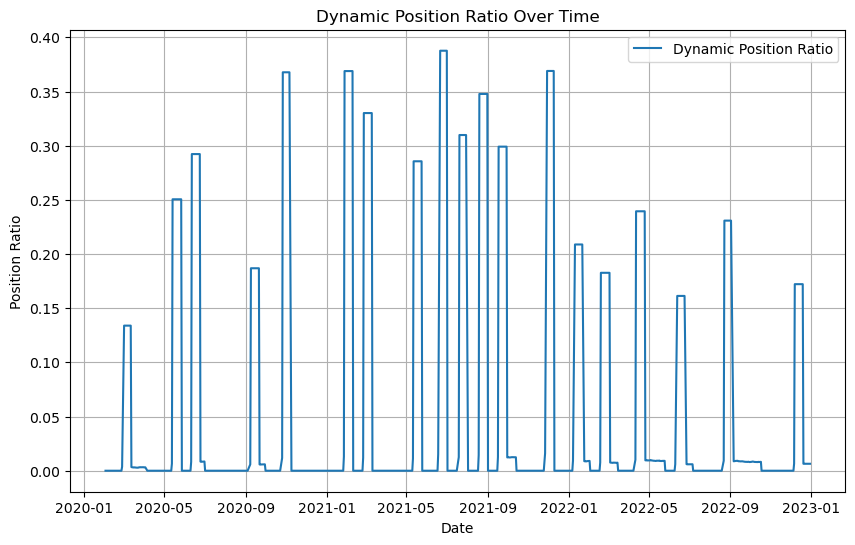

In [30]:
def backtest_with_dynamic_position_and_tracking(data, initial_balance=10000, cooldown=10):
    """
    Backtest dynamic position sizing with tracking.

    Returns:
        tuple: Final portfolio value and a list of daily positions.
    """
    balance = initial_balance
    position = 0
    last_trade = -cooldown
    position_ratios = []  

    for i in range(1, len(data)):
        if i - last_trade < cooldown:
            position_ratios.append(position)  
            continue

        if data["GARCH_Volatility"].iloc[i] > 0:
            position_ratio = min(1, 1 / (data["GARCH_Volatility"].iloc[i] * 100))
        else:
            position_ratio = 1

        invest_amount = balance * position_ratio

        if data["Adj Close"].iloc[i] < data["LowerBound"].iloc[i] and position == 0:
            position = invest_amount / data["Adj Close"].iloc[i]
            balance -= invest_amount
            last_trade = i
        elif data["Adj Close"].iloc[i] > data["UpperBound"].iloc[i] and position > 0:
            balance += position * data["Adj Close"].iloc[i]
            position = 0
            last_trade = i

        position_ratios.append(position * data["Adj Close"].iloc[i] / (balance + position * data["Adj Close"].iloc[i]))

    final_value = balance + position * data["Adj Close"].iloc[-1]
    return final_value, position_ratios


final_value_dynamic, position_ratios = backtest_with_dynamic_position_and_tracking(data, initial_balance=10000, cooldown=10)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(data.index[1:], position_ratios, label="Dynamic Position Ratio")
plt.title("Dynamic Position Ratio Over Time")
plt.xlabel("Date")
plt.ylabel("Position Ratio")
plt.legend()
plt.grid()
plt.show()


In [32]:

position_ratios = list(position_ratios) + [1]  

returns_dynamic = data["Daily Return"] * position_ratios[:-1]


metrics_dynamic = calculate_metrics(data, returns_dynamic)


print("\nDynamic Positioning Strategy Metrics:")
for metric, value in metrics_dynamic.items():
    print(f"{metric}: {value:.2%}" if metric != "Sharpe Ratio" else f"{metric}: {value:.2f}")




Dynamic Positioning Strategy Metrics:
Max Drawdown: -6.47%
Annualized Return: -1.68%
Sharpe Ratio: -0.54


In [34]:
def backtest_with_optimized_volatility(data, smoothing_factor, initial_balance=10000, cooldown=10):
    """
    Backtest dynamic position sizing with optimized volatility coefficient.
    """
    balance = initial_balance
    position = 0
    last_trade = -cooldown
    position_ratios = []

    for i in range(1, len(data)):

        if i - last_trade < cooldown:
            if len(position_ratios) > 0:
                position_ratios.append(position_ratios[-1]) 
            else:
                position_ratios.append(0)  
            continue

        if data["GARCH_Volatility"].iloc[i] > 0:
            position_ratio = min(1, smoothing_factor / (data["GARCH_Volatility"].iloc[i] * 100))
        else:
            position_ratio = 1

        invest_amount = balance * position_ratio

        if data["Adj Close"].iloc[i] < data["LowerBound"].iloc[i] and position == 0:
            position = invest_amount / data["Adj Close"].iloc[i]
            balance -= invest_amount
            last_trade = i
        elif data["Adj Close"].iloc[i] > data["UpperBound"].iloc[i] and position > 0:
            balance += position * data["Adj Close"].iloc[i]
            position = 0
            last_trade = i


        total_portfolio_value = balance + position * data["Adj Close"].iloc[i]
        position_ratios.append(position * data["Adj Close"].iloc[i] / total_portfolio_value)

    while len(position_ratios) < len(data):
        position_ratios.append(position_ratios[-1])

    final_value = balance + position * data["Adj Close"].iloc[-1]
    return final_value, position_ratios

smoothing_factors = [0.5, 1, 1.5, 2]
results = []

for factor in smoothing_factors:
    final_value, position_ratios = backtest_with_optimized_volatility(data, smoothing_factor=factor, initial_balance=10000, cooldown=10)
    returns_dynamic = data["Daily Return"] * position_ratios  # 确保两者长度一致
    metrics = calculate_metrics(data, returns_dynamic)
    results.append((factor, metrics["Max Drawdown"], metrics["Annualized Return"], metrics["Sharpe Ratio"]))


for result in results:
    print(f"Smoothing Factor: {result[0]:.2f}, Max Drawdown: {result[1]:.2%}, "
          f"Annualized Return: {result[2]:.2%}, Sharpe Ratio: {result[3]:.2f}")


Smoothing Factor: 0.50, Max Drawdown: -0.23%, Annualized Return: -0.08%, Sharpe Ratio: -1.05
Smoothing Factor: 1.00, Max Drawdown: -0.46%, Annualized Return: -0.15%, Sharpe Ratio: -1.05
Smoothing Factor: 1.50, Max Drawdown: -0.69%, Annualized Return: -0.23%, Sharpe Ratio: -1.05
Smoothing Factor: 2.00, Max Drawdown: -0.93%, Annualized Return: -0.31%, Sharpe Ratio: -1.05
